# 🔍 Fake News Detector — ISOT Dataset
> **Goal:** Build an AI system that classifies news articles as *Real* or *Fake* using a fine-tuned DistilBERT transformer, with confidence scores and explainability.

---
### 📋 Pipeline Overview
```
1. Environment Setup
2. Data Loading & Exploration (EDA)
3. Preprocessing & Cleaning
4. Tokenization (DistilBERT)
5. Model Training & Fine-Tuning
6. Evaluation (Accuracy, F1, ROC-AUC, Confusion Matrix)
7. Explainability (LIME — why is this article suspicious?)
8. Interactive Inference Demo
```

## 1. 📦 Environment Setup

In [1]:
# Install required packages (run once)
!pip install transformers datasets torch scikit-learn pandas numpy matplotlib seaborn lime tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 98.6 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 whic

In [2]:
import os
import re
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.notebook import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

warnings.filterwarnings('ignore')

#  Reproducibility 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device 
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {DEVICE}")
print(f"🔥 PyTorch version: {torch.__version__}")

✅ Using device: cuda
🔥 PyTorch version: 2.10.0+cu128


## 2. 📂 Data Loading

> **Download the ISOT dataset from Kaggle:**  
> https://www.kaggle.com/datasets/emineyetm/fake-news-detection-datasets  
> Extract and place `Fake.csv` and `True.csv` in the same folder as this notebook.  
> Alternatively the cell below will attempt to download via `kaggle` CLI if configured.

In [3]:
# Try to auto-download via Kaggle CLI (optional)
def try_kaggle_download():
    try:
        import subprocess
        result = subprocess.run(
            ['kaggle', 'datasets', 'download', '-d',
             'emineyetm/fake-news-detection-datasets', '--unzip'],
            capture_output=True, text=True, timeout=120
        )
        if result.returncode == 0:
            print("✅ Dataset downloaded via Kaggle CLI")
            return True
        else:
            print("⚠️  Kaggle CLI failed. Please download manually.")
            return False
    except Exception:
        return False

if not (os.path.exists('/kaggle/input/datasets/emineyetm/fake-news-detection-datasets/News _dataset/Fake.csv') and os.path.exists('/kaggle/input/datasets/emineyetm/fake-news-detection-datasets/News _dataset/True.csv')):
    print("📥 Attempting auto-download...")
    try_kaggle_download()
else:
    print("✅ Dataset files found locally.")

✅ Dataset files found locally.


In [4]:
# Load CSVs 
fake_df = pd.read_csv('/kaggle/input/datasets/emineyetm/fake-news-detection-datasets/News _dataset/Fake.csv')
true_df = pd.read_csv('/kaggle/input/datasets/emineyetm/fake-news-detection-datasets/News _dataset/True.csv')

fake_df['label'] = 0   # 0 = Fake
true_df['label'] = 1   # 1 = Real

df = pd.concat([fake_df, true_df], ignore_index=True)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)  # shuffle

print(f"📰 Total articles : {len(df):,}")
print(f"   ├─ Fake        : {(df.label==0).sum():,}")
print(f"   └─ Real        : {(df.label==1).sum():,}")
df.head(3)

📰 Total articles : 44,898
   ├─ Fake        : 23,481
   └─ Real        : 21,417


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1


## 3. 🔎 Exploratory Data Analysis (EDA)

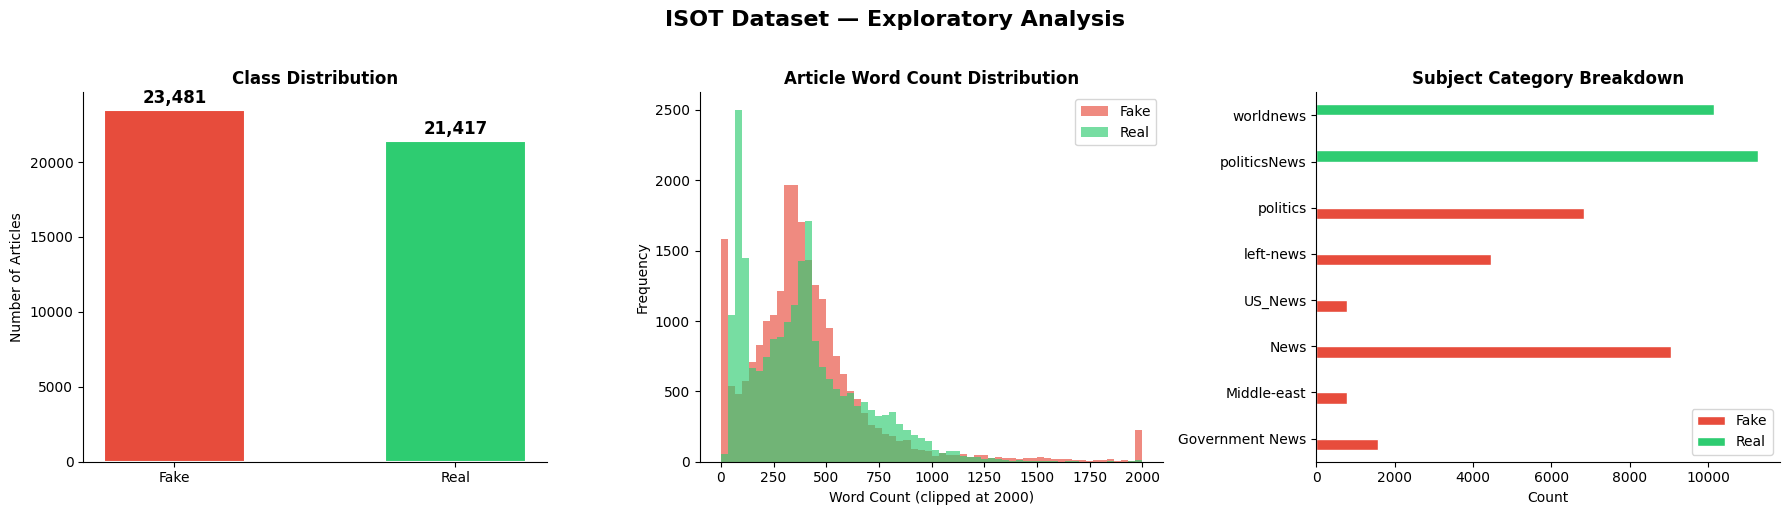


📊 EDA plots saved as eda_plots.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ISOT Dataset — Exploratory Analysis', fontsize=16, fontweight='bold', y=1.02)

PALETTE = {0: '#E74C3C', 1: '#2ECC71'}
LABELS  = {0: 'Fake', 1: 'Real'}

# 1. Class Distribution 
counts = df['label'].value_counts().sort_index()
bars = axes[0].bar(
    [LABELS[i] for i in counts.index],
    counts.values,
    color=[PALETTE[i] for i in counts.index],
    edgecolor='white', linewidth=1.5, width=0.5
)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Articles')
axes[0].spines[['top','right']].set_visible(False)

# 2. Text Length Distribution 
df['text_len'] = df['text'].fillna('').apply(lambda x: len(x.split()))
for label, color in PALETTE.items():
    subset = df[df.label == label]['text_len']
    axes[1].hist(subset.clip(upper=2000), bins=60, alpha=0.65,
                 color=color, label=LABELS[label], edgecolor='none')
axes[1].set_title('Article Word Count Distribution', fontweight='bold')
axes[1].set_xlabel('Word Count (clipped at 2000)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

# 3. Subject Distribution
subj_counts = df.groupby(['subject','label']).size().unstack(fill_value=0)
subj_counts.columns = [LABELS[c] for c in subj_counts.columns]
subj_counts.plot(kind='barh', ax=axes[2],
                 color=[PALETTE[0], PALETTE[1]], edgecolor='white')
axes[2].set_title('Subject Category Breakdown', fontweight='bold')
axes[2].set_xlabel('Count')
axes[2].set_ylabel('')
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 EDA plots saved as eda_plots.png")

In [6]:
# Basic stats 
print("📈 Word Count Statistics by Class")
print(df.groupby('label')['text_len'].describe().rename(index={0:'Fake',1:'Real'}).round(1))

📈 Word Count Statistics by Class
         count   mean    std  min    25%    50%    75%     max
label                                                         
Fake   23481.0  423.2  408.4  0.0  240.0  363.0  506.0  8135.0
Real   21417.0  385.6  274.0  0.0  148.0  359.0  525.0  5172.0


## 4. 🧹 Text Preprocessing

In [7]:
def clean_text(text: str) -> str:
    """Light cleaning — preserve semantics for BERT."""
    if not isinstance(text, str):
        return ""
    # Remove Reuters/AP datelines  (e.g. "WASHINGTON (Reuters) - ")
    text = re.sub(r'^[A-Z\s,]+\(Reuters\)\s*[-–]\s*', '', text)
    text = re.sub(r'^[A-Z\s,]+\(AP\)\s*[-–]\s*', '', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Remove excessive whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def build_input(row: pd.Series) -> str:
    """Combine title + first 400 words of body for richer context."""
    title = clean_text(str(row.get('title', '')))
    body  = clean_text(str(row.get('text',  '')))
    body_short = ' '.join(body.split()[:400])   # truncate before tokenizer
    return f"{title} [SEP] {body_short}"


tqdm.pandas(desc="Cleaning")
df['input_text'] = df.progress_apply(build_input, axis=1)

# Drop rows with empty input
df = df[df['input_text'].str.strip().ne('')].reset_index(drop=True)
print(f"✅ Cleaned. Total usable rows: {len(df):,}")
print("\nSample input:")
print(df['input_text'].iloc[0][:300], '...')

Cleaning:   0%|          | 0/44898 [00:00<?, ?it/s]

✅ Cleaned. Total usable rows: 44,898

Sample input:
Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution [SEP] 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative state ...


## 5. ✂️ Train / Validation / Test Split

In [8]:
# 70% train | 15% val | 15% test  
X = df['input_text'].values
y = df['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

print(f"Train : {len(X_train):>6,} samples")
print(f"Val   : {len(X_val):>6,} samples")
print(f"Test  : {len(X_test):>6,} samples")

Train : 31,428 samples
Val   :  6,735 samples
Test  :  6,735 samples


## 6. 🔡 Tokenization & Dataset

In [9]:
MODEL_NAME  = 'distilbert-base-uncased'
MAX_LEN     = 256
BATCH_SIZE  = 16

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
print(f"✅ Tokenizer loaded: {MODEL_NAME}")


class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(),
            'attention_mask' : encoding['attention_mask'].squeeze(),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }


train_dataset = NewsDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = NewsDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = NewsDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"\nBatches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizer loaded: distilbert-base-uncased

Batches — Train: 1965 | Val: 421 | Test: 421


## 7. 🤖 Model Setup

In [10]:
NUM_EPOCHS   = 3
LR           = 2e-5
WARMUP_RATIO = 0.1

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: 'FAKE', 1: 'REAL'},
    label2id={'FAKE': 0, 'REAL': 1}
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model: {MODEL_NAME}")
print(f"   ├─ Total params    : {total_params/1e6:.1f}M")
print(f"   └─ Trainable params: {trainable_params/1e6:.1f}M")

total_steps   = len(train_loader) * NUM_EPOCHS
warmup_steps  = int(WARMUP_RATIO * total_steps)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"\n⚙️  Training config:")
print(f"   Epochs: {NUM_EPOCHS} | LR: {LR} | Warmup steps: {warmup_steps} | Total steps: {total_steps}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model: distilbert-base-uncased
   ├─ Total params    : 67.0M
   └─ Trainable params: 67.0M

⚙️  Training config:
   Epochs: 3 | LR: 2e-05 | Warmup steps: 589 | Total steps: 5895


## 8. 🏋️ Training Loop

In [11]:
def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    total_loss = 0.0

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels)
            total_loss += outputs.loss.item()

            probs  = torch.softmax(outputs.logits, dim=-1)
            preds  = torch.argmax(probs, dim=-1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())  # prob of REAL

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, acc, f1, all_preds, all_labels, all_probs


# Training 
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
best_val_f1   = 0.0
best_model_path = 'best_fake_news_model.pt'

print("🚀 Starting training...\n")

for epoch in range(1, NUM_EPOCHS + 1):
    # Train phase 
    model.train()
    train_loss = 0.0
    train_preds, train_labels_list = [], []

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [Train]")
    for batch in pbar:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['label'].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels)
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=-1)
        train_preds.extend(preds.cpu().numpy())
        train_labels_list.extend(labels.cpu().numpy())

        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    avg_train_loss = train_loss / len(train_loader)
    train_acc      = accuracy_score(train_labels_list, train_preds)

    # Validation phase 
    val_loss, val_acc, val_f1, _, _, _ = evaluate(model, val_loader, DEVICE)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"\n{'='*65}")
    print(f"  Epoch {epoch}/{NUM_EPOCHS}")
    print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f}   | Val   Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), best_model_path)
        print(f"  💾 Best model saved (Val F1 = {best_val_f1:.4f})")

print(f"\n✅ Training complete. Best Val F1: {best_val_f1:.4f}")

🚀 Starting training...



Epoch 1/3 [Train]:   0%|          | 0/1965 [00:00<?, ?it/s]


  Epoch 1/3
  Train Loss: 0.0712 | Train Acc: 0.9737
  Val   Loss: 0.0068   | Val   Acc: 0.9982 | Val F1: 0.9982
  💾 Best model saved (Val F1 = 0.9982)


Epoch 2/3 [Train]:   0%|          | 0/1965 [00:00<?, ?it/s]


  Epoch 2/3
  Train Loss: 0.0048 | Train Acc: 0.9988
  Val   Loss: 0.0061   | Val   Acc: 0.9988 | Val F1: 0.9988
  💾 Best model saved (Val F1 = 0.9988)


Epoch 3/3 [Train]:   0%|          | 0/1965 [00:00<?, ?it/s]


  Epoch 3/3
  Train Loss: 0.0010 | Train Acc: 0.9999
  Val   Loss: 0.0064   | Val   Acc: 0.9990 | Val F1: 0.9990
  💾 Best model saved (Val F1 = 0.9990)

✅ Training complete. Best Val F1: 0.9990


## 9. 📈 Training Curves

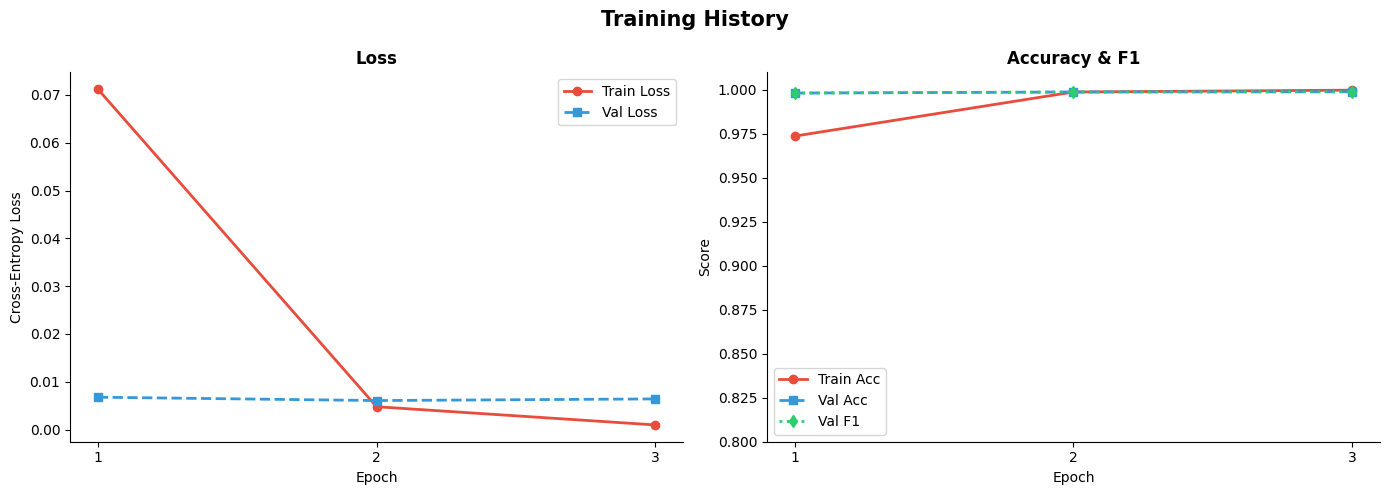

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=15, fontweight='bold')

epochs_x = range(1, NUM_EPOCHS + 1)

# Loss
axes[0].plot(epochs_x, history['train_loss'], 'o-', color='#E74C3C', label='Train Loss', lw=2)
axes[0].plot(epochs_x, history['val_loss'],   's--', color='#3498DB', label='Val Loss',   lw=2)
axes[0].set_title('Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)
axes[0].set_xticks(epochs_x)

# Accuracy
axes[1].plot(epochs_x, history['train_acc'], 'o-', color='#E74C3C', label='Train Acc', lw=2)
axes[1].plot(epochs_x, history['val_acc'],   's--', color='#3498DB', label='Val Acc',   lw=2)
axes[1].plot(epochs_x, history['val_f1'],    'd:',  color='#2ECC71', label='Val F1',    lw=2)
axes[1].set_title('Accuracy & F1', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score')
axes[1].legend(); axes[1].spines[['top','right']].set_visible(False)
axes[1].set_xticks(epochs_x); axes[1].set_ylim(0.8, 1.01)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. 🧪 Final Evaluation on Test Set

In [13]:
# Load best weights 
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()
print(f"✅ Best model loaded from: {best_model_path}")

test_loss, test_acc, test_f1, test_preds, test_labels, test_probs = evaluate(
    model, test_loader, DEVICE)

roc_auc = roc_auc_score(test_labels, test_probs)

print("\n" + "="*55)
print("  📊  TEST SET RESULTS")
print("="*55)
print(f"  Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  F1 Score  : {test_f1:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print(f"  Loss      : {test_loss:.4f}")
print("="*55)
print("\n📋 Detailed Classification Report:")
print(classification_report(test_labels, test_preds, target_names=['FAKE', 'REAL']))

✅ Best model loaded from: best_fake_news_model.pt

  📊  TEST SET RESULTS
  Accuracy  : 0.9990  (99.90%)
  F1 Score  : 0.9990
  ROC-AUC   : 1.0000
  Loss      : 0.0042

📋 Detailed Classification Report:
              precision    recall  f1-score   support

        FAKE       1.00      1.00      1.00      3523
        REAL       1.00      1.00      1.00      3212

    accuracy                           1.00      6735
   macro avg       1.00      1.00      1.00      6735
weighted avg       1.00      1.00      1.00      6735



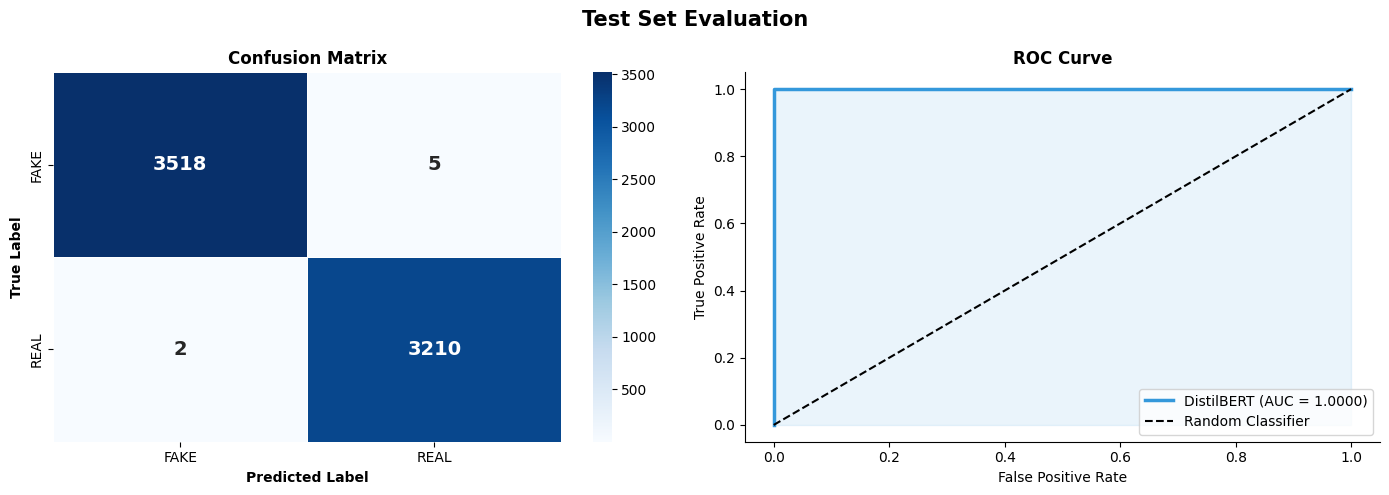

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Test Set Evaluation', fontsize=15, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['FAKE','REAL'],
            yticklabels=['FAKE','REAL'],
            ax=axes[0], linewidths=0.5, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontweight='bold')
axes[0].set_ylabel('True Label', fontweight='bold')

# ROC Curve 
fpr, tpr, _ = roc_curve(test_labels, test_probs)
axes[1].plot(fpr, tpr, color='#3498DB', lw=2.5,
             label=f'DistilBERT (AUC = {roc_auc:.4f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1.5, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#3498DB')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. 💡 Explainability Why is this article suspicious?

> Uses **LIME** (Local Interpretable Model-Agnostic Explanations) to highlight the words that most influenced the model's prediction.

In [15]:
from lime.lime_text import LimeTextExplainer

LIME_CLASS_NAMES = ['FAKE', 'REAL']
explainer = LimeTextExplainer(class_names=LIME_CLASS_NAMES)


def predict_proba_fn(texts: list) -> np.ndarray:
    """Wrapper for LIME: takes a list of strings, returns probabilities."""
    model.eval()
    all_probs = []
    batch_size = 8
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i : i + batch_size]
        enc = tokenizer(
            batch_texts,
            max_length=MAX_LEN,
            padding=True,
            truncation=True,
            return_tensors='pt'
        )
        with torch.no_grad():
            outputs = model(
                input_ids      = enc['input_ids'].to(DEVICE),
                attention_mask = enc['attention_mask'].to(DEVICE)
            )
        probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()
        all_probs.append(probs)
    return np.vstack(all_probs)


print("✅ LIME explainer ready.")

✅ LIME explainer ready.


True label: FAKE

════════════════════════════════════════════════════════════
  🔎 PREDICTION  : 🔴 FAKE
  📊 CONFIDENCE  : 100.00%
  📝 Input (first 200 chars): MEET THE NASTY WOMEN Responsible For Promoting Hate And Intolerance On Nazi-Themed Trump Billboard [VIDEO] [SEP] A menacing Donald Trump is gazing down on Phoenix s Grand Avenue.The president is flank...
════════════════════════════════════════════════════════════

💡 Top 15 influential words for 'FAKE' prediction:
Rank  Word                      Influence    Direction
-------------------------------------------------------
1     Intolerance               +0.0000      ▲ Pushes FAKE
2     Phoenix                   +0.0000      ▲ Pushes FAKE
3     get                       +0.0000      ▲ Pushes FAKE
4     day                       +0.0000      ▲ Pushes FAKE
5     really                    +0.0000      ▲ Pushes FAKE
6     through                   +0.0000      ▲ Pushes FAKE
7     master                    +0.0000      ▲ Pushes FAKE
8

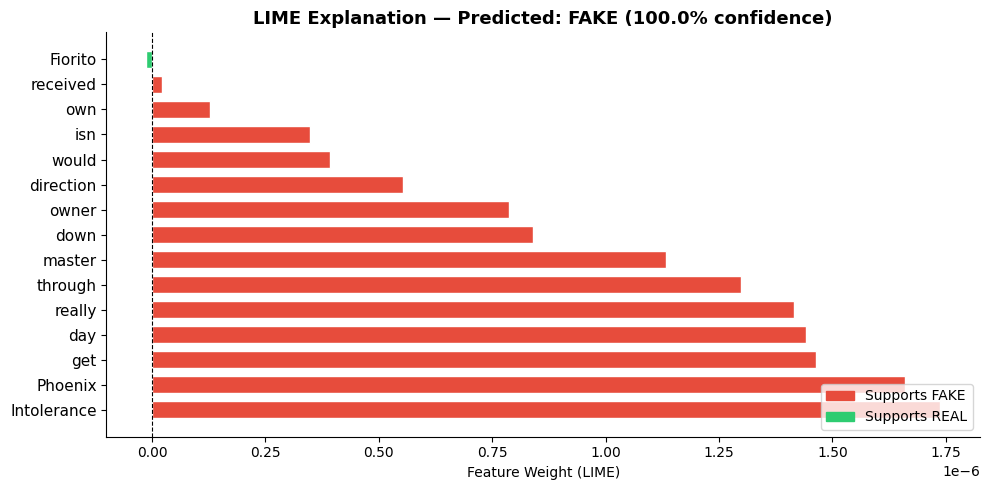

(0, np.float32(0.9999913))

In [18]:
def explain_prediction(text: str, num_features: int = 15, num_samples: int = 500):
    """Run LIME explanation and show highlighted words."""
    exp = explainer.explain_instance(
        text,
        predict_proba_fn,
        num_features=num_features,
        num_samples=num_samples,
        top_labels=2          # ← ask LIME to explain both classes
    )

    probs  = predict_proba_fn([text])[0]
    label  = int(np.argmax(probs))
    conf   = probs[label]

    print("\n" + "═"*60)
    print(f"  🔎 PREDICTION  : {'🔴 FAKE' if label == 0 else '🟢 REAL'}")
    print(f"  📊 CONFIDENCE  : {conf*100:.2f}%")
    print(f"  📝 Input (first 200 chars): {text[:200]}...")
    print("═"*60)

    # Feature importance table 
    feats = exp.as_list(label=label)          # ← now works because top_labels=2
    print(f"\n💡 Top {len(feats)} influential words for '{LIME_CLASS_NAMES[label]}' prediction:")
    print(f"{'Rank':<5} {'Word':<25} {'Influence':<12} {'Direction'}")
    print("-" * 55)
    for rank, (word, weight) in enumerate(feats, 1):
        direction = "▲ Pushes FAKE" if (label == 0 and weight > 0) or (label == 1 and weight < 0) else "▲ Pushes REAL"
        print(f"{rank:<5} {word:<25} {weight:>+.4f}      {direction}")

    # Plot 
    words, weights = zip(*feats)
    if label == 0:
        colors = ['#E74C3C' if w > 0 else '#2ECC71' for w in weights]
    else:
        colors = ['#2ECC71' if w > 0 else '#E74C3C' for w in weights]

    fig, ax = plt.subplots(figsize=(10, 5))
    y_pos = range(len(words))
    ax.barh(y_pos, weights, color=colors, edgecolor='white', height=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontsize=11)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(
        f"LIME Explanation — Predicted: {'FAKE' if label==0 else 'REAL'} ({conf*100:.1f}% confidence)",
        fontweight='bold', fontsize=13
    )
    ax.set_xlabel('Feature Weight (LIME)')
    red_patch   = mpatches.Patch(color='#E74C3C', label='Supports FAKE')
    green_patch = mpatches.Patch(color='#2ECC71', label='Supports REAL')
    ax.legend(handles=[red_patch, green_patch], loc='lower right')
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('lime_explanation.png', dpi=150, bbox_inches='tight')
    plt.show()
    return label, conf

# Explain a test sample 
sample_idx  = 0
sample_text = X_test[sample_idx]
true_label  = y_test[sample_idx]
print(f"True label: {'REAL' if true_label == 1 else 'FAKE'}")
explain_prediction(sample_text)

## 12. 🎯 Interactive Inference — Test Your Own Article


🔴 Prediction  : FAKE
📊 Confidence   : 100.00%
   ├─ P(FAKE)   : 100.00%
   └─ P(REAL)   : 0.00%

⏳ Running LIME explanation (may take ~30 seconds)...

════════════════════════════════════════════════════════════
  🔎 PREDICTION  : 🔴 FAKE
  📊 CONFIDENCE  : 100.00%
  📝 Input (first 200 chars): NASA Confirms Earth Will Experience 6 Days of Total Darkness in December Due to Solar Storm [SEP] NASA has officially confirmed that Earth will experience an unprecedented period of total darkness las...
════════════════════════════════════════════════════════════

💡 Top 15 influential words for 'FAKE' prediction:
Rank  Word                      Influence    Direction
-------------------------------------------------------
1     NASA                      +0.0091      ▲ Pushes FAKE
2     s                         +0.0083      ▲ Pushes FAKE
3     already                   -0.0066      ▲ Pushes REAL
4     media                     -0.0065      ▲ Pushes REAL
5     gets                      +0.0065     

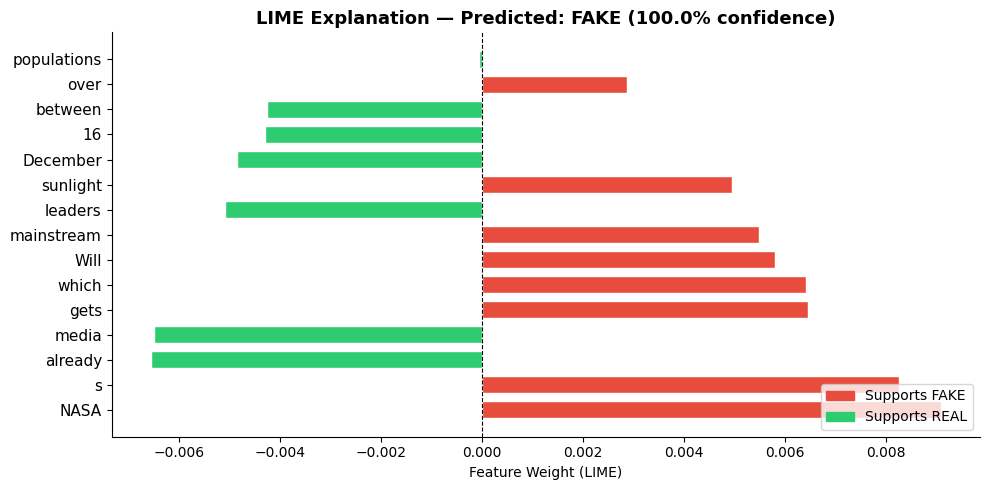


📦 Result dict: {'label': 'FAKE', 'confidence': '100.00%', 'fake_prob': '100.00%', 'real_prob': '0.00%'}


In [22]:
def predict_article(title: str, body: str = "", explain: bool = True) -> dict:
    """
    Full inference pipeline.
    
    Parameters
    ----------
    title   : Article headline
    body    : Article body text (optional but improves accuracy)
    explain : Whether to run LIME explanation (slower)
    
    Returns
    -------
    dict with keys: label, confidence, fake_prob, real_prob
    """
    body_clean  = clean_text(body)
    title_clean = clean_text(title)
    body_short  = ' '.join(body_clean.split()[:400])
    input_text  = f"{title_clean} [SEP] {body_short}".strip()

    probs  = predict_proba_fn([input_text])[0]
    label  = int(np.argmax(probs))
    conf   = float(probs[label])
    result = {
        'label'      : LIME_CLASS_NAMES[label],
        'confidence' : f"{conf*100:.2f}%",
        'fake_prob'  : f"{probs[0]*100:.2f}%",
        'real_prob'  : f"{probs[1]*100:.2f}%",
    }

    emoji = '🔴' if label == 0 else '🟢'
    print(f"\n{emoji} Prediction  : {LIME_CLASS_NAMES[label]}")
    print(f"📊 Confidence   : {conf*100:.2f}%")
    print(f"   ├─ P(FAKE)   : {probs[0]*100:.2f}%")
    print(f"   └─ P(REAL)   : {probs[1]*100:.2f}%")

    if explain:
        print("\n⏳ Running LIME explanation (may take ~30 seconds)...")
        explain_prediction(input_text)

    return result


# Fake news example 

my_title = "NASA Confirms Earth Will Experience 6 Days of Total Darkness in December Due to Solar Storm"
my_body  = """
NASA has officially confirmed that Earth will experience an unprecedented period of total 
darkness lasting six consecutive days this coming December. According to NASA spokesperson 
Dr. John Malley, a rare alignment of planets combined with an extreme solar storm will 
block all sunlight from reaching Earth between December 16 and December 22.

The agency is urging citizens to stock up on candles, food, and emergency supplies before 
the event occurs. Several governments have already begun distributing survival kits to 
their populations. The mainstream media has been ordered to suppress this information to 
avoid mass panic, which is why you may not have heard about it through official channels.

Scientists at NASA's secret underground facility in Nevada have been preparing for this 
event for over a decade. A leaked internal memo obtained by independent journalists 
confirms that world leaders were briefed in private last month. Share this article 
immediately before it gets removed from the internet.
"""

result = predict_article(my_title, my_body, explain=True)
print("\n📦 Result dict:", result)

In [20]:
# Real news example 
real_title = "Federal Reserve Holds Interest Rates Steady Amid Cooling Inflation Data"
real_body  = """
The Federal Reserve left its benchmark interest rate unchanged on Wednesday, pausing its 
aggressive rate-hiking campaign as recent data showed inflation continuing to ease toward 
the central bank's 2% target.

The decision, which was unanimous among Fed policymakers, keeps the federal funds rate 
in the target range of 5.25% to 5.50%, where it has stood since July. Fed Chair Jerome 
Powell said at a press conference following the announcement that officials want to see 
more evidence that inflation is sustainably declining before considering any rate cuts.

"We are committed to returning inflation to our 2 percent goal," Powell said. "We believe 
our policy rate may be at or near its peak for this tightening cycle, but we are prepared 
to tighten further if appropriate."

The Consumer Price Index rose 3.2% year-over-year in October, down sharply from a peak 
of 9.1% in June 2022. Markets rallied following the announcement, with the S&P 500 
closing up 1.2% on the day.
"""

result2 = predict_article(real_title, real_body, explain=False)  
print("\n📦 Result dict:", result2)


🟢 Prediction  : REAL
📊 Confidence   : 100.00%
   ├─ P(FAKE)   : 0.00%
   └─ P(REAL)   : 100.00%

📦 Result dict: {'label': 'REAL', 'confidence': '100.00%', 'fake_prob': '0.00%', 'real_prob': '100.00%'}


## 13. 💾 Save Model & Tokenizer

In [21]:
SAVE_DIR = './fake_news_detector_model'
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"✅ Model & tokenizer saved to: {SAVE_DIR}")
print("\nTo reload later:")
print("  from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast")
print(f"  model     = DistilBertForSequenceClassification.from_pretrained('{SAVE_DIR}')")
print(f"  tokenizer = DistilBertTokenizerFast.from_pretrained('{SAVE_DIR}')")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model & tokenizer saved to: ./fake_news_detector_model

To reload later:
  from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast
  model     = DistilBertForSequenceClassification.from_pretrained('./fake_news_detector_model')
  tokenizer = DistilBertTokenizerFast.from_pretrained('./fake_news_detector_model')
